# Hierarchical Bayesian Modelling For Component Integrity

This notebook models the degradation of component integrity over time and compares two probabilistic models with a downstream machine-learning baseline.

The Bayesian models share information across components through hierarchical priors while allowing each component to have its own initial integrity and decay rate. The enhanced model additionally uses component covariates to explain differences in decay. Posterior predictive uncertainty is evaluated globally and per component, then used to estimate outcomes for a blind set of components.

**Workflow:**

1. Load component-level time-series data and separate observed and blind components.
2. Define baseline and covariate-enhanced hierarchical Student-t models.
3. Fit both models with NumPyro and NUTS.
4. Compare posterior diagnostics, predictive accuracy, uncertainty coverage, and PSIS-LOO scores.
5. Generate blind-set probabilities and compare the Bayesian model with a random-forest predictor.

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro import render_model
import arviz as az

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# Device and global settings
jax.config.update('jax_platform_name', 'cpu')
numpyro.set_host_device_count(4)
print(f"Using NumPyro {numpyro.__version__}")

c:\Users\cjogi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using NumPyro 0.21.0


In [2]:

# Load CSV
data = pd.read_csv("component-data-2c.csv")

print(data.describe())

# Pop out target values
y = data["integrity"].to_numpy()

# Store ID column before dropping
IDs = data['ID'].to_numpy()

comp_idx = data['index'].to_numpy()
t = data['day'].to_numpy()
X_cov = data[['X1','X2','X3','X4','X5']].to_numpy()
n_comp = len(np.unique(comp_idx))
unique_comps = np.unique(comp_idx)
X_comp = np.vstack([ X_cov[comp_idx == cid][0] for cid in unique_comps ])

# 1) Define a train/test mask on components:
train_mask   = comp_idx < 50               # indices 0–49 → train
test_mask    = comp_idx >= 50              # indices 50–74 → blind test

# 2) Extract training arrays (only obs from first 50 components):
comp_idx_tr  = comp_idx[train_mask]
t_tr         = t[train_mask]
y_tr         = y[train_mask]
X_tr         = X_cov[train_mask] 


            index          X1          X2          X3          X4          X5  \
count  879.000000  879.000000  879.000000  879.000000  879.000000  879.000000   
mean    28.574516    1.427949    1.599667    1.217749    2.263046    1.429958   
std     17.999331    1.480370    1.553415    1.165267    3.493584    1.624554   
min      0.000000    0.140000    0.044000    0.078000    0.162000    0.123000   
25%     14.000000    0.529000    0.700000    0.477000    0.683000    0.388000   
50%     31.000000    1.004000    1.220000    0.749000    1.075000    0.723000   
75%     42.000000    1.539000    1.891500    1.455000    1.992000    1.982000   
max     74.000000    9.175000   15.516000    6.821000   14.272000   12.921000   

              day   integrity  
count  879.000000  879.000000  
mean    17.081911   51.858481  
std     11.142385   22.288919  
min      0.000000    1.825000  
25%      7.000000   34.226500  
50%     15.000000   51.989000  
75%     26.000000   70.292500  
max     45.000

## Define The Hierarchical Models

Two models are compared:

- **Baseline:** each component has an individual intercept and decay rate, with population-level priors that partially pool those component parameters.
- **Enhanced:** the decay rate is adjusted by a learned linear combination of the component covariates $X_1,\ldots,X_5$.

Both models use a Student-t observation distribution, which is more robust to occasional outlying integrity measurements than a Gaussian likelihood. The shared hyperparameters describe the population while component-level parameters capture individual trajectories.

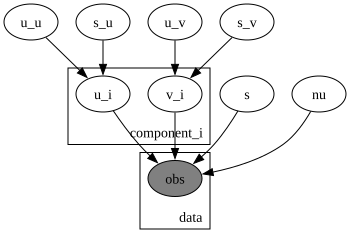

In [3]:
def baseline_model(n_comp, comp, t, y):

  # Hyperpriors for the parameters
  u_u = numpyro.sample("u_u", dist.TruncatedNormal(90, 5, low=0, high=100))
  s_u = numpyro.sample("s_u", dist.HalfNormal(3))
  u_v = numpyro.sample("u_v", dist.TruncatedNormal(3, 2, low=0))
  s_v = numpyro.sample("s_v", dist.HalfNormal(3))

  with numpyro.plate("component_i", n_comp):
    # u is the intercept taking a value between 80-100
    u = numpyro.sample("u_i", dist.TruncatedNormal(u_u, s_u, low=0, high=100))
    # v is the decay rate taking a value between 1-10
    v = numpyro.sample("v_i", dist.TruncatedNormal(u_v, s_v, low=0))
  
  # sigma is the sd of the gaussian noise
  s = numpyro.sample("s", dist.HalfNormal(3))
  
  # Function for each time point
  f = u[comp] * jnp.exp(-v[comp] * t / 100)

  # Scaling factor for degrees-of-freedom
  nu = numpyro.sample("nu", dist.Exponential(3))

  with numpyro.plate("data", len(comp)):  
    # observation model
    numpyro.sample("obs", dist.StudentT(nu, f, s), obs=y)
  
numpyro.render_model(baseline_model, model_args=(n_comp, comp_idx, t, y))


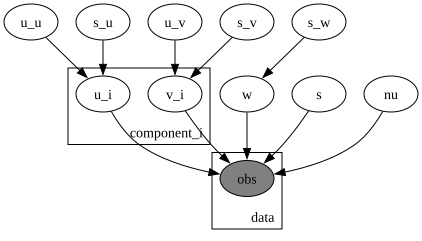

In [4]:
def enhanced_model(n_comp, comp, t, y, X):
    # Hyperpriors
    u_u = numpyro.sample("u_u", dist.TruncatedNormal(90, 5, low=0, high=100))
    s_u = numpyro.sample("s_u", dist.HalfNormal(3))
    u_v = numpyro.sample("u_v", dist.TruncatedNormal(3, 2, low=0))
    s_v = numpyro.sample("s_v", dist.HalfNormal(3))

    # Per-component intercept and decay
    with numpyro.plate("component_i", n_comp):
        u = numpyro.sample("u_i", dist.TruncatedNormal(u_u, s_u, low=0, high=100))
        v = numpyro.sample("v_i", dist.TruncatedNormal(u_v, s_v, low=0))

    s_w = numpyro.sample("s_w", dist.HalfNormal(3))

    # Covariate weights
    w = numpyro.sample("w", dist.Normal(0, s_w).expand([X.shape[1]]))

    # Observation noise
    s = numpyro.sample("s", dist.HalfNormal(3))

    # Covariate-adjusted mean
    f = u[comp] * jnp.exp(-(v[comp] + jnp.dot(X, w)) * (t / 100))

    # Scaling factor for degrees-of-freedom
    nu = numpyro.sample("nu", dist.Exponential(3))

    with numpyro.plate("data", len(t)):
        numpyro.sample("obs", dist.StudentT(nu, f, s), obs=y)

numpyro.render_model(enhanced_model, model_args=(n_comp, comp_idx, t, y, X_cov))


## Bayesian Inference

Each model is fitted with NumPyro's NUTS sampler using multiple chains, a warm-up phase, and posterior draws. The helper function returns both raw posterior samples and ArviZ inference data so that the same fitted results can support diagnostics, predictions, and model comparison.

In [5]:
num_warmup = 2000
num_samples = 2000
rng = jax.random.PRNGKey(42)



def run_mcmc(model, args, warmup=num_warmup, samples=num_samples, rng=rng, chains=4):
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains)
    mcmc.run(rng, *args)
    mcmc.print_summary()
    idata = az.from_numpyro(mcmc)
    return mcmc.get_samples(), idata

In [6]:
# Run baseline
base_samples, base_idata = run_mcmc(baseline_model, (n_comp, comp_idx_tr, t_tr, y_tr))

Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4000 [00:04<?, ?it/s]



Running chain 0:   5%|▌         | 200/4000 [00:06<00:28, 135.58it/s]


Running chain 0:  10%|█         | 400/4000 [00:07<00:17, 200.92it/s]


Running chain 0:  15%|█▌        | 600/4000 [00:07<00:13, 256.68it/s]


Running chain 0:  20%|██        | 800/4000 [00:08<00:10, 307.91it/s]

Running chain 0:  30%|███       | 1200/4000 [00:09<00:07, 361.56it/s]


Running chain 0:  35%|███▌      | 1400/4000 [00:09<00:06, 380.73it/s]


Running chain 0:  45%|████▌     | 1800/4000 [00:10<00:05, 379.38it/s]


Running chain 0:  50%|█████     | 2000/4000 [00:11<00:06, 309.02it/s]


Running chain 0:  55%|█████▌    | 2200/4000 [00:12<00:06, 283.41it/s]


Running chain 0:  60%|██████    | 2400/4000 [00:13<00:07, 227.14it/s]


Running chain 0:  65%|██████▌   | 2600/4000 [00:14<00:06, 223.27it/s]


Running chain 0:  70%|███████   | 2800/4000 [00:15<00:05, 239.49it/s]


Running chain 0:  75


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        nu      5.67      0.87      5.59      4.28      7.07   9675.80      1.00
         s      4.31      0.16      4.31      4.05      4.58   9640.38      1.00
       s_u      5.52      1.03      5.40      3.92      7.21   2041.65      1.00
       s_v      1.58      0.22      1.56      1.22      1.91   2430.04      1.00
    u_i[0]     94.17      2.24     94.19     90.56     97.90   5740.12      1.00
    u_i[1]     87.52      4.61     87.51     80.00     95.25   6760.55      1.00
    u_i[2]     97.78      1.56     98.03     95.61    100.00   6830.96      1.00
    u_i[3]     90.49      2.05     90.49     87.23     93.95   8297.21      1.00
    u_i[4]     87.16      3.67     87.21     81.41     93.52   8957.58      1.00
    u_i[5]     89.67      3.85     89.72     83.37     96.07   8349.68      1.00
    u_i[6]     92.30      3.31     92.34     86.92     97.89   6511.73      1.00
    u_i[7]     85.32      4

array([[<Axes: title={'center': 'u_i'}>, <Axes: title={'center': 'u_i'}>],
       [<Axes: title={'center': 'v_i'}>, <Axes: title={'center': 'v_i'}>],
       [<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

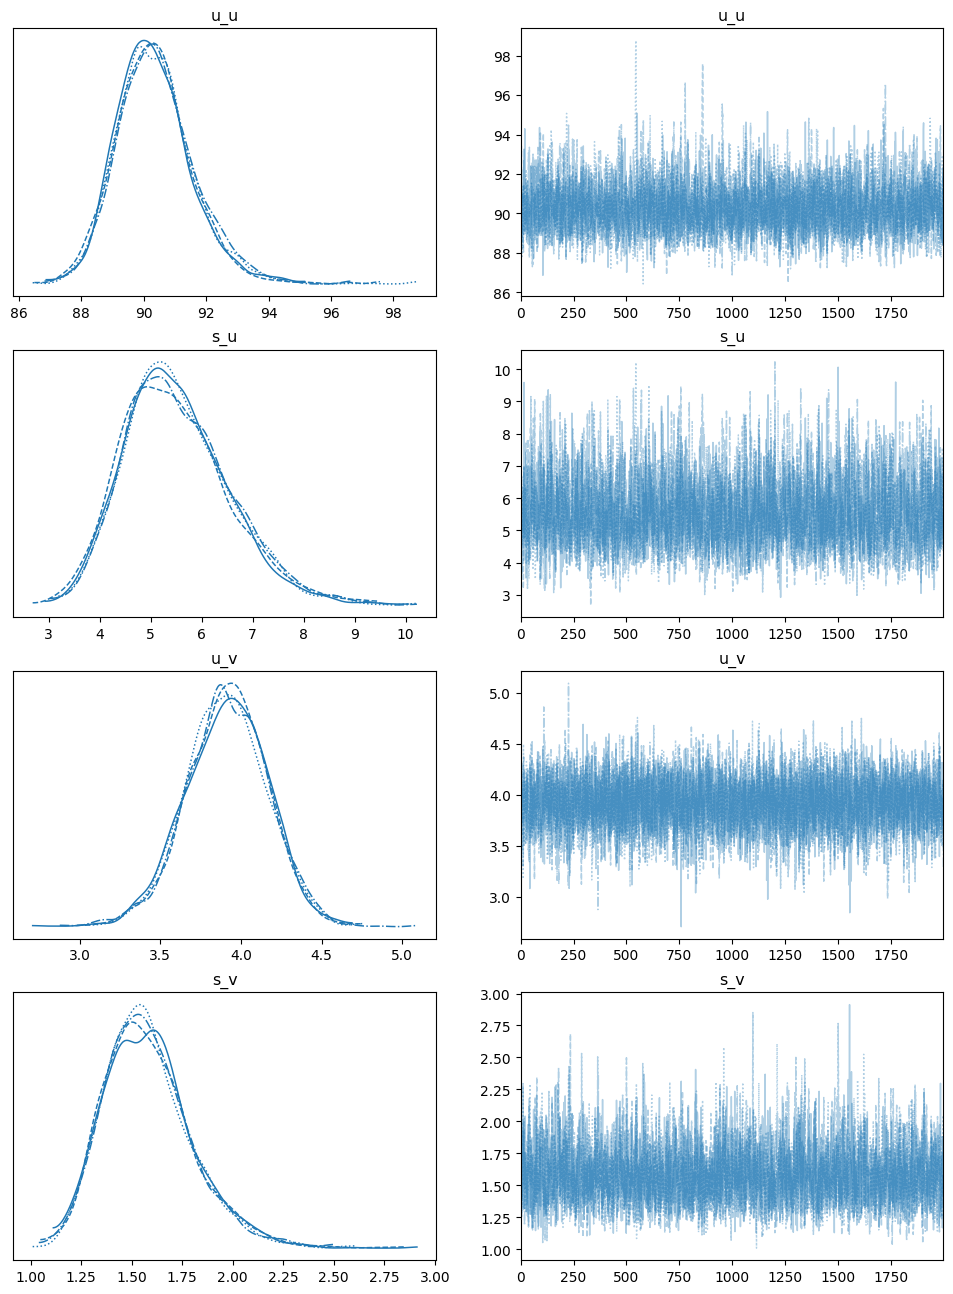

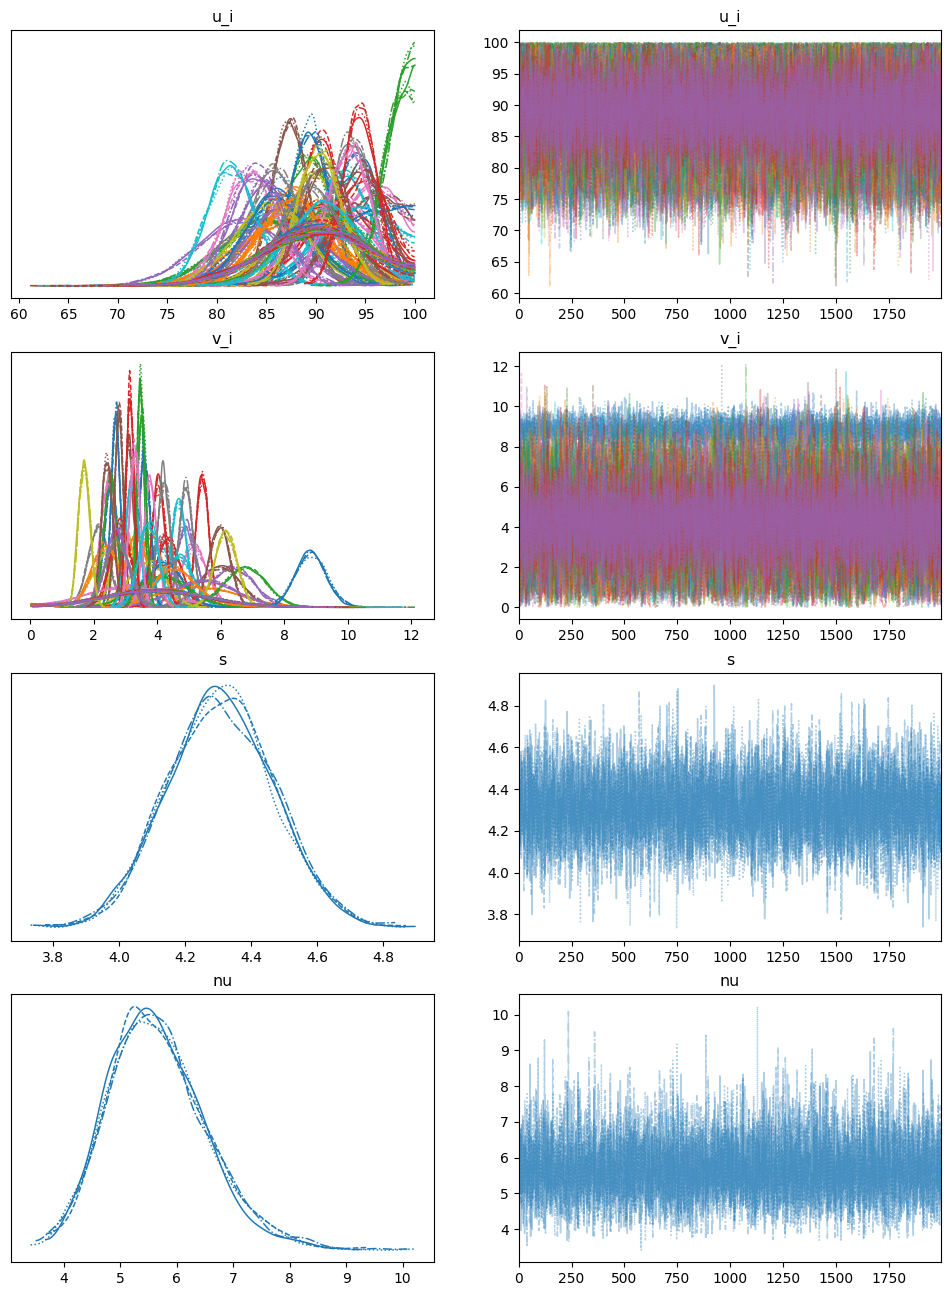

In [7]:
az.plot_trace(base_idata, compact=True, figsize=(12,16), var_names=['u_u','s_u','u_v','s_v'])
az.plot_trace(base_idata, compact=True, figsize=(12,16), var_names=['u_i','v_i','s','nu'])

In [8]:
# Run enhanced
enh_samples, enh_idata = run_mcmc(enhanced_model, (n_comp, comp_idx_tr, t_tr, y_tr, X_tr))


Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4000 [00:06<?, ?it/s]





Running chain 0:   5%|▌         | 200/4000 [00:09<01:09, 54.86it/s]


Running chain 0:  15%|█▌        | 600/4000 [00:10<00:22, 153.11it/s]


Running chain 0:  20%|██        | 800/4000 [00:11<00:16, 191.11it/s]


Running chain 0:  25%|██▌       | 1000/4000 [00:12<00:13, 222.84it/s]


Running chain 0:  30%|███       | 1200/4000 [00:12<00:11, 254.43it/s]


Running chain 0:  35%|███▌      | 1400/4000 [00:13<00:09, 276.75it/s]


Running chain 0:  40%|████      | 1600/4000 [00:13<00:08, 297.90it/s]


Running chain 0:  45%|████▌     | 1800/4000 [00:14<00:07, 309.33it/s]


Running chain 0:  50%|█████     | 2000/4000 [00:15<00:06, 296.19it/s]


Running chain 0:  55%|█████▌    | 2200/4000 [00:16<00:06, 283.69it/s]


Running chain 0:  60%|██████    | 2400/4000 [00:16<00:05, 283.21it/s]


Running chain 0:  65%|██████▌   | 2600/4000 [00:17<00:04, 289.70it/s]


Running chain 0: 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        nu      5.69      0.85      5.63      4.32      7.04   8613.80      1.00
         s      4.31      0.16      4.31      4.05      4.56   7414.66      1.00
       s_u      5.29      0.96      5.18      3.76      6.75   1446.25      1.00
       s_v      0.36      0.07      0.36      0.24      0.47    980.89      1.00
       s_w      0.65      0.32      0.57      0.27      1.03   5240.09      1.00
    u_i[0]     94.45      2.19     94.48     90.93     98.18   4910.01      1.00
    u_i[1]     92.06      3.94     92.11     85.96     98.77   4765.75      1.00
    u_i[2]     97.76      1.52     97.97     95.69    100.00   6855.67      1.00
    u_i[3]     90.79      1.98     90.79     87.70     94.18   9259.99      1.00
    u_i[4]     88.93      3.16     88.93     83.71     94.13   7977.42      1.00
    u_i[5]     88.04      3.46     88.04     82.56     93.82   8667.43      1.00
    u_i[6]     91.97      2

array([[<Axes: title={'center': 's_w'}>, <Axes: title={'center': 's_w'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

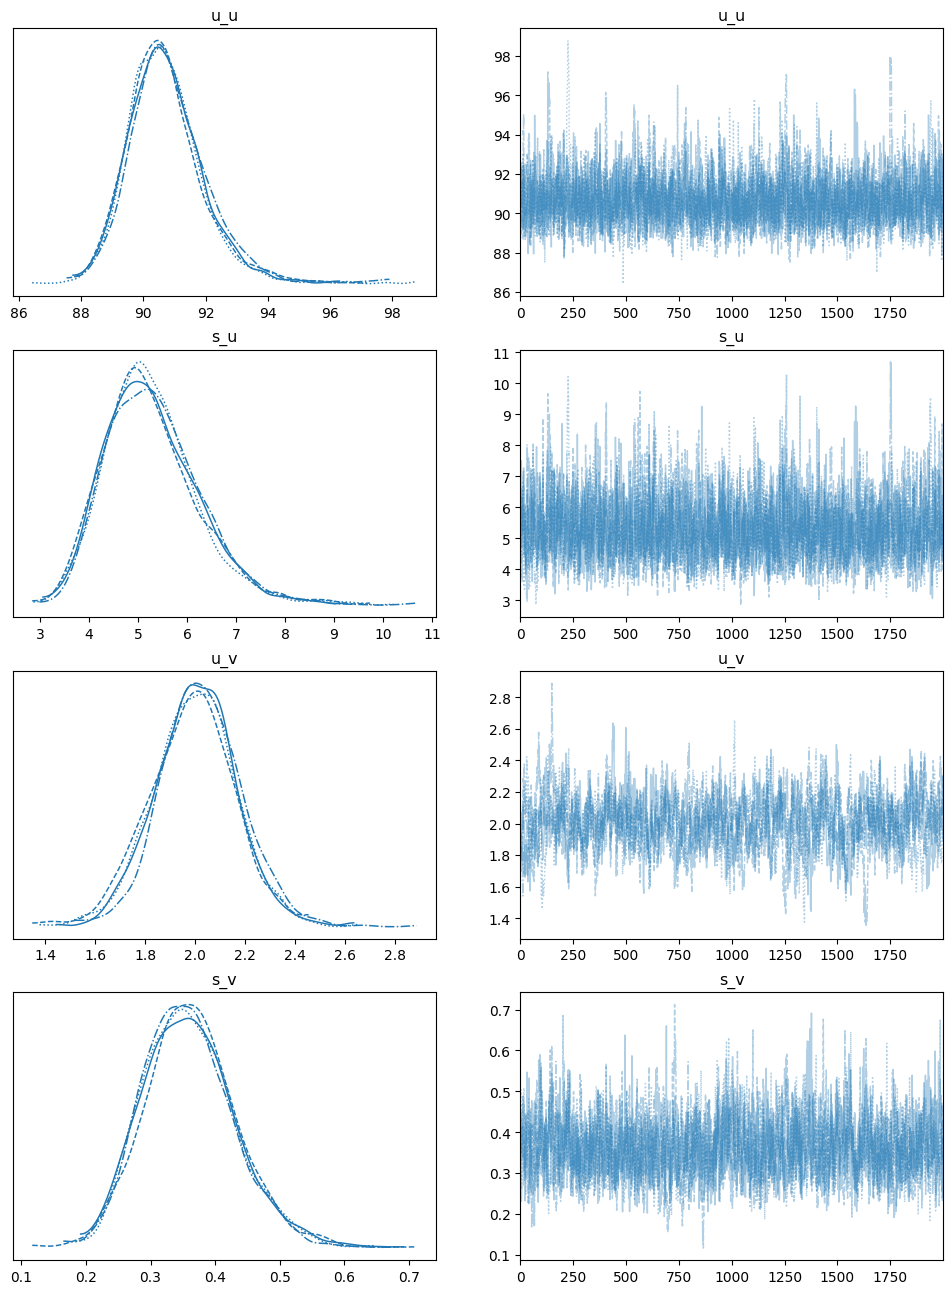

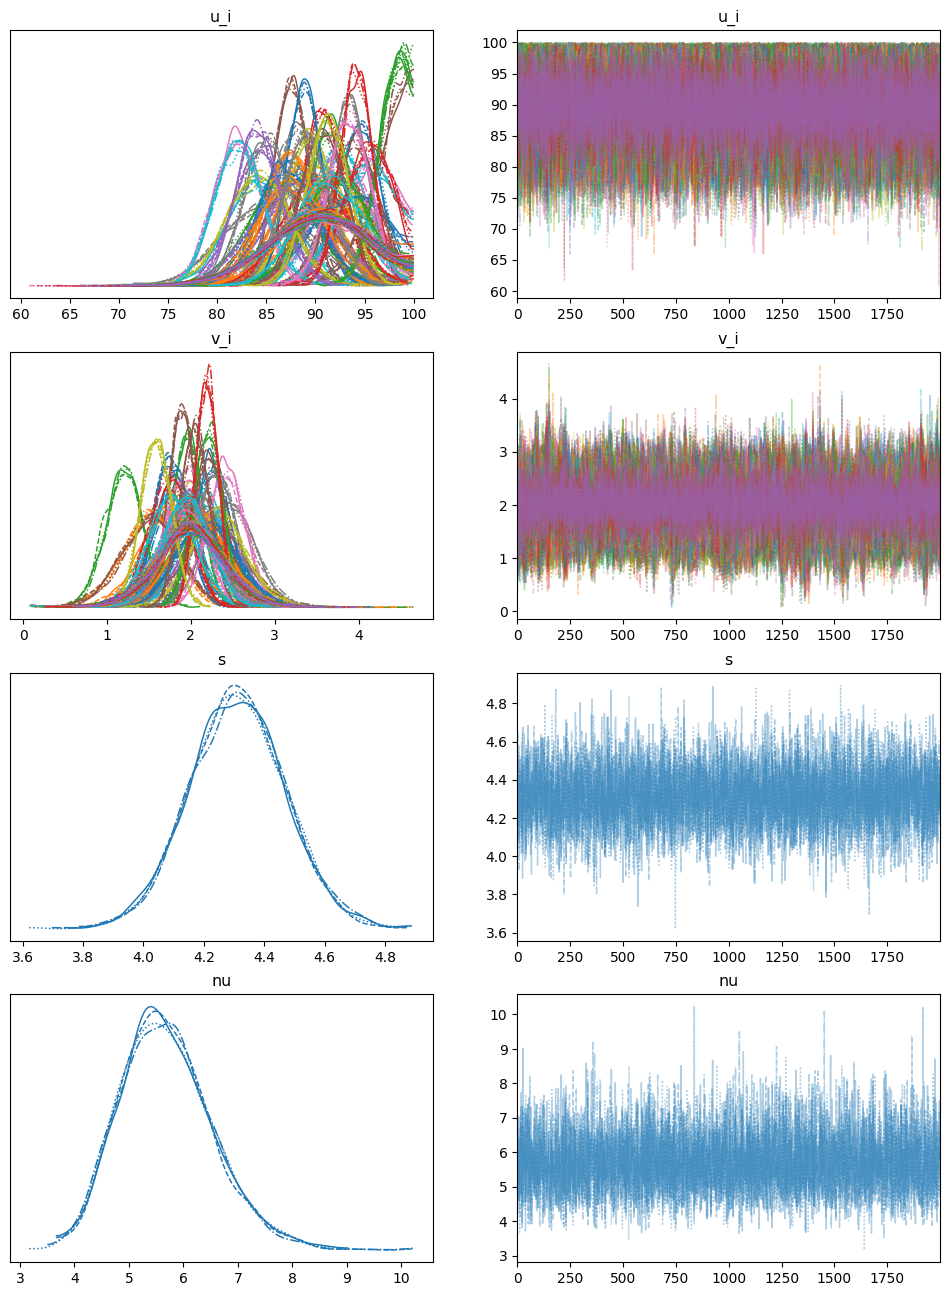

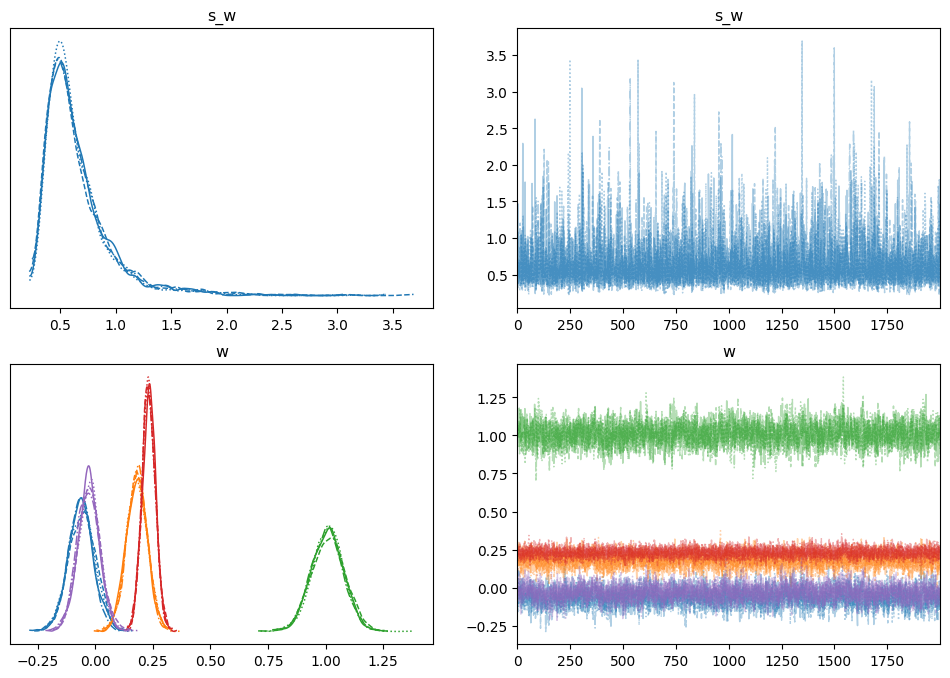

In [9]:
az.plot_trace(enh_idata, compact=True, figsize=(12,16), var_names=['u_u','s_u','u_v','s_v'])
az.plot_trace(enh_idata, compact=True, figsize=(12,16), var_names=['u_i','v_i','s','nu'])


az.plot_trace(enh_idata, compact=True, figsize=(12,8), var_names=['s_w','w'])

In [10]:
print("Baseline Model Summary")
az.summary(base_idata, var_names=['u_u','s_u','u_v','s_v','s','nu'])

Baseline Model Summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
u_u,90.348,1.228,88.229,92.754,0.024,0.017,2702.0,3279.0,1.0
s_u,5.516,1.035,3.664,7.428,0.023,0.016,2019.0,3773.0,1.0
u_v,3.911,0.252,3.444,4.380,0.004,0.003,5021.0,4253.0,1.0
s_v,1.581,0.219,1.206,2.006,0.004,0.003,2577.0,3597.0,1.0
s,4.309,0.163,4.014,4.623,0.002,0.001,9609.0,6088.0,1.0
nu,5.670,0.869,4.115,7.336,0.009,0.006,9976.0,5979.0,1.0


In [11]:
print("Enhanced Model Summary")
az.summary(enh_idata, var_names=['u_u','s_u','u_v','s_v','s','nu','s_w','w'])

Enhanced Model Summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
u_u,90.734,1.252,88.471,92.991,0.032,0.023,1824.0,1957.0,1.00
s_u,5.286,0.965,3.597,7.060,0.025,0.018,1513.0,2523.0,1.00
u_v,2.003,0.166,1.699,2.329,0.008,0.006,427.0,887.0,1.01
s_v,0.360,0.071,0.231,0.492,0.002,0.002,1013.0,1836.0,1.00
s,4.311,0.157,4.031,4.622,0.002,0.001,7421.0,6147.0,1.00
nu,5.693,0.849,4.209,7.323,0.009,0.006,8619.0,6441.0,1.00
s_w,0.652,0.316,0.264,1.190,0.004,0.003,9481.0,4573.0,1.00
w[0],-0.061,0.057,-0.169,0.044,0.001,0.001,1492.0,3039.0,1.00
w[1],0.180,0.045,0.093,0.265,0.001,0.001,1909.0,3824.0,1.00
w[2],1.009,0.071,0.877,1.140,0.002,0.001,1581.0,2482.0,1.00


## Assess The Models

The assessment combines point accuracy and uncertainty quality. Predictions are summarised with RMSE and MAE, while 95% predictive intervals are assessed through empirical coverage and mean interval width.

Pareto-smoothed importance sampling leave-one-out cross-validation adds a model-level comparison through `elpd_loo`, its standard error, the effective number of parameters, and Pareto-$k$ diagnostics. Results are also broken down by selected components to show how the models behave on individual trajectories rather than only in aggregate.

In [12]:
def get_posterior_predictions(samples, obs_t, obs_comp, X_comp=None, return_samples: bool=False):
    u_obs = samples['u_i'][:, obs_comp]
    v_obs = samples['v_i'][:, obs_comp]

    # Include weights if Enhanced model
    if 'w' in samples and X_comp is not None:
        w     = samples['w']
        X_obs = X_comp[obs_comp]
        effect = v_obs + w.dot(X_obs.T)  
    else:
        effect = v_obs 

    t_mat   = obs_t[None, :] 
    f_samps = u_obs * jnp.exp(-effect * (t_mat/100.0))

    f_mean   = np.array(f_samps.mean(axis=0))
    f_var    = np.array(f_samps.var(axis=0))
    f_sd     = np.sqrt(f_var)
    s  = samples['s']
    total_sd = np.sqrt(f_var + np.mean(s**2))

    if return_samples:
        return f_samps, f_mean, f_sd, total_sd
    else:
        return f_mean, f_sd, total_sd

def compute_global_metrics(y_true, y_pred, total_sd):
    errors = y_true - y_pred
    return {
        'RMSE':     np.sqrt(np.mean(errors**2)),
        'MAE':      np.mean(np.abs(errors)),
        'Coverage': np.mean(np.abs(errors) <= 1.96 * total_sd),
        'MeanWidth': np.mean(2 * 1.96 * total_sd)
    }

def compute_per_component_metrics(y_true, y_pred, total_sd, obs_comp):
    comp_metrics = {}
    for cid in np.unique(obs_comp):
        mask = obs_comp == cid
        errs = y_true[mask] - y_pred[mask]
        sd_c  = total_sd[mask]
        comp_metrics[cid] = {
            'RMSE':     np.sqrt(np.mean(errs**2)),
            'MAE':      np.mean(np.abs(errs)),
            'Coverage': np.mean(np.abs(errs) <= 1.96 * sd_c),
            'MeanWidth': np.mean(2 * 1.96 * sd_c)
        }
    return comp_metrics

def error_rms(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def plot_prediction(t_obs, y_obs, t_grid, f_mean, f_sd, total_sd, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(t_obs, y_obs, color='k', s=20)
    ax.plot(t_grid, f_mean, lw=2)
    ax.fill_between(t_grid,
                    f_mean-1.96*f_sd, f_mean+1.96*f_sd,
                    alpha=0.3, label='Function CI 95%')
    ax.fill_between(t_grid,
                    f_mean-1.96*total_sd, f_mean+1.96*total_sd,
                    alpha=0.2, label='Overall CI 95%')
    ax.set_xlim(0,60); ax.set_ylim(0,110)
    ax.set_xlabel('Time (days)'); ax.set_ylabel('Integrity')
    return ax

def plot_component(comp_id, x, y, samples, sampler, ax=None):
    t_grid = np.linspace(0,60,200)
    mask   = (comp_idx == comp_id)
    t_obs, y_obs = t[mask], y[mask]

    comp_grid = np.full_like(t_grid, comp_id, dtype=int)

    if sampler == "Enhanced":
        f_mean, f_sd, total_sd = get_posterior_predictions(samples, t_grid, comp_grid, X_comp)
    else:
        f_mean, f_sd, total_sd = get_posterior_predictions(samples, t_grid, comp_grid)

    f_interp = np.interp(t_obs, t_grid, f_mean)
    rmse_val = error_rms(y_obs, f_interp)

    ax = plot_prediction(t_obs, y_obs, t_grid,
                         f_mean, f_sd, total_sd, ax=ax)
    ax.set_title(f"Component {comp_id}, {sampler}, RMSE: {rmse_val:.3f}")
    return ax

def plot_four(components, x, y, samples, sampler):
    fig, axes = plt.subplots(2,2, figsize=(12,10),
                             sharex=True, sharey=True)
    for ax, cid in zip(axes.flatten(), components):
        plot_component(cid, x, y, samples, sampler, ax=ax)
        ax.legend()
    fig.tight_layout()
    plt.show()



c:\Users\cjogi\AppData\Local\Programs\Python\Python313\Lib\site-packages\arviz\stats\stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Global performance metrics:
               RMSE       MAE  Coverage  MeanWidth     elpd_loo    elpd_se  \
Baseline  5.530449  4.143391  0.930603  19.296762 -2492.109727  20.804359   
Enhanced  5.027940  3.956853  0.934016  18.279100 -2483.740817  20.901377   

              p_loo  
Baseline  75.148811  
Enhanced  63.366163  
Computed from 8000 posterior samples and 805 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2492.11    20.80
p_loo       75.15        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      804   99.9%
   (0.70, 1]   (bad)         1    0.1%
   (1, Inf)   (very bad)    0    0.0%

Computed from 8000 posterior samples and 805 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2483.74    20.90
p_loo       63.37        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf,

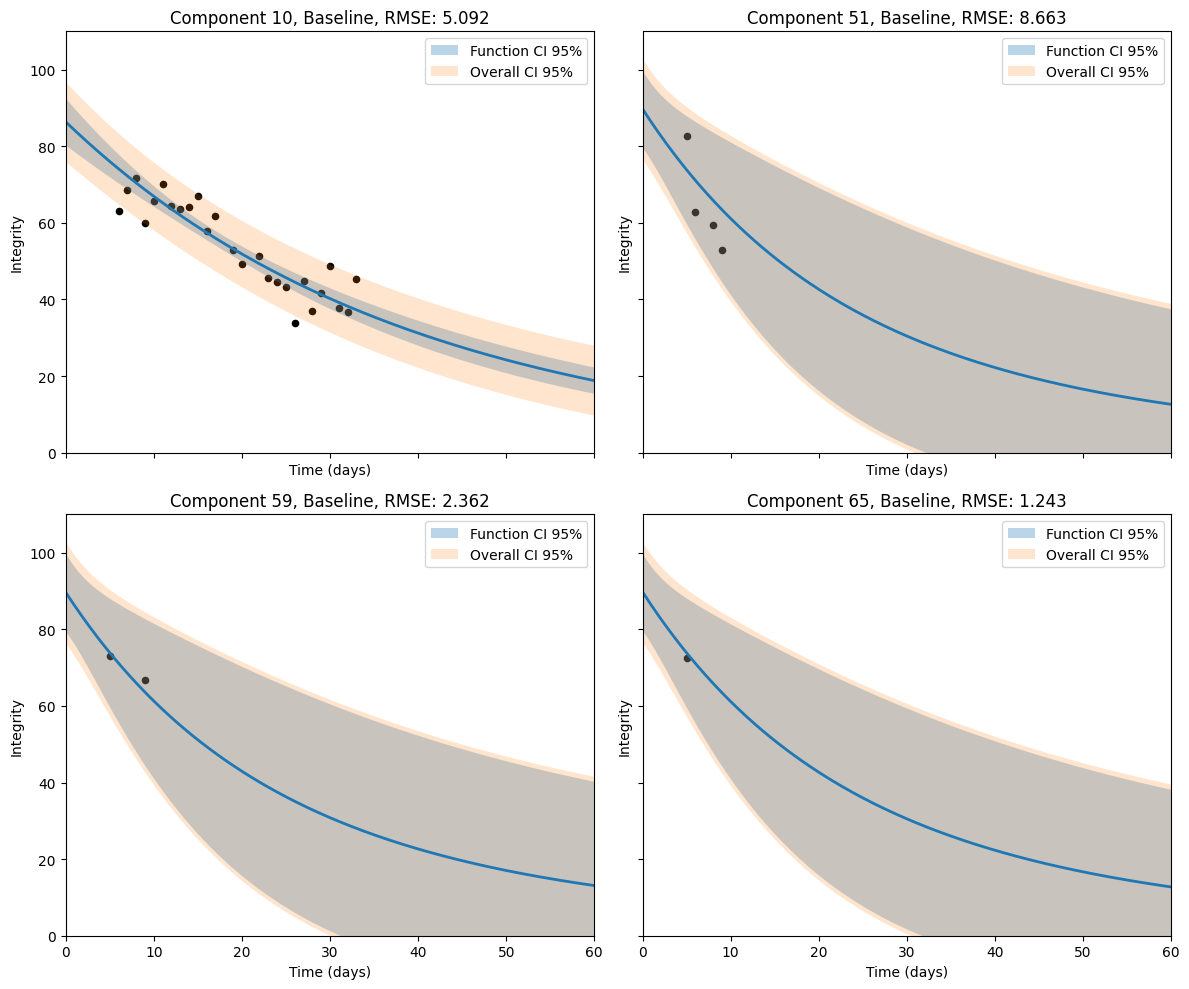

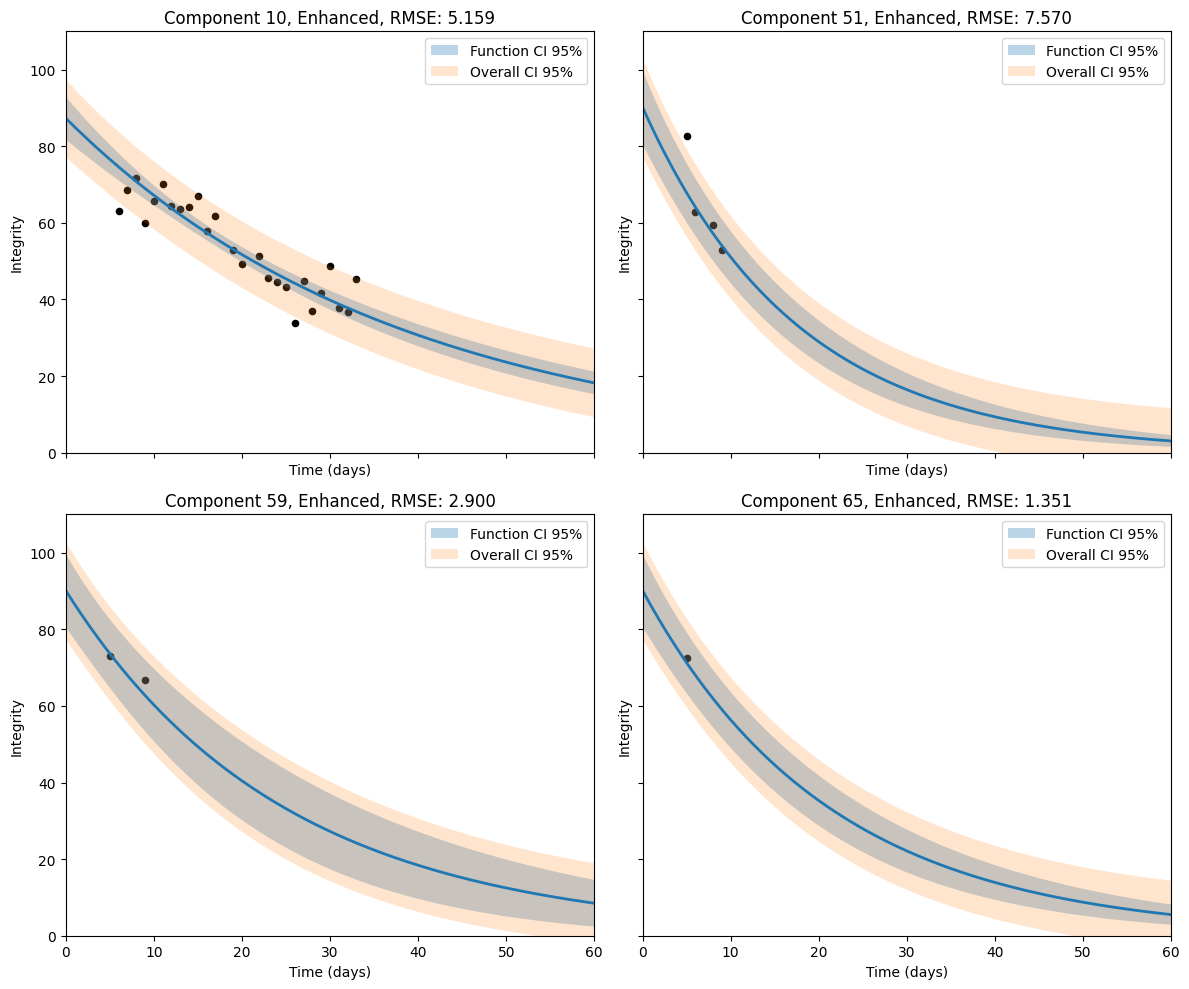

In [13]:
# Global Values

# Base predictions
base_mean, base_fsd, base_total_sd = get_posterior_predictions(base_samples, t, comp_idx)
base_global = compute_global_metrics(y, base_mean, base_total_sd)
# Enhanced predictions
enh_mean, enh_fsd, enh_total_sd = get_posterior_predictions(enh_samples, t, comp_idx, X_comp)
enh_global  = compute_global_metrics(y, enh_mean, enh_total_sd)

# Compute Pareto-smoothed importance sampling
loo_base = az.loo(base_idata)
loo_enh  = az.loo(enh_idata)

# Display global metrics
metrics_df = pd.DataFrame(
    [base_global, enh_global],
    index=["Baseline", "Enhanced"]
)

metrics_df['elpd_loo'] = [loo_base.elpd_loo, loo_enh.elpd_loo]
metrics_df['elpd_se']  = [loo_base.se, loo_enh.se]
metrics_df['p_loo']    = [loo_base.p_loo, loo_enh.p_loo]

print("Global performance metrics:\n", metrics_df)

# Print full diagnostic to check Pareto K values
print(loo_base)
print(loo_enh)


# Per Component Values

# Base and enhanced predictions
base_percomp = compute_per_component_metrics(y, base_mean, base_total_sd, comp_idx)
enh_percomp = compute_per_component_metrics(y, enh_mean, enh_total_sd, comp_idx)


comps = [10,51,59,65]

base_table = pd.DataFrame.from_dict(
    {cid: base_percomp[cid] for cid in comps}, orient='index'
)
enh_table  = pd.DataFrame.from_dict(
    {cid: enh_percomp[cid] for cid in comps}, orient='index'
)

print("\nBaseline per-component metrics:\n", base_table)
print("\nEnhanced per-component metrics:\n", enh_table)

plot_four(comps, X_cov, y, base_samples, "Baseline")
plot_four(comps, X_cov, y, enh_samples, "Enhanced")

## Blind-Set Predictions

For components held out from the observed training subset, the enhanced posterior is evaluated at day 30. The notebook records the posterior probability that integrity is at or below the chosen threshold and writes those predictions to `predictions.csv`.

In [14]:
test_indices = np.arange(50, 75)
obs_t = np.full(test_indices.shape, 30.0)
obs_comp = test_indices

f_samps, f_mean, f_sd, total_sd = get_posterior_predictions(enh_samples, obs_t, obs_comp, X_comp, return_samples=True)

threshold = 30.0
probs = np.mean(f_samps <= threshold, axis=0)

output_df = pd.DataFrame({
    'ID':         [IDs[comp_idx == cid][0] for cid in test_indices],
    'index':      test_indices,
    'probability': probs
})

output_df.to_csv('predictions.csv', index=False)


## Black-Box Comparison

The final section builds a conventional feature-based predictor for comparison. Early measurements are summarised into descriptive features such as mean integrity, variability, slope, intercept, and the last observed value; component covariates are included as additional predictors.

A random-forest regressor is trained on available components and evaluated on a held-out component split. Its day-30 predictions are overlaid on the Bayesian trajectory plots, making the difference between a black-box point prediction and a hierarchical posterior prediction visible.

In [15]:
def get_main_and_blind_sets(df, main_min, bayes_test=None):
    bayes_test = bayes_test or []
    main_comps = [
        cid for cid, grp in df.groupby('index')
        if (grp['day'] <= 30).sum() >= main_min
    ]
    return sorted(main_comps), bayes_test


def create_features(df, comps, cov_cols=None):
    cov_cols = cov_cols or ['X1','X2','X3','X4','X5']
    records = []
    for cid in comps:
        early = df[(df['index']==cid) & (df['day'] <= 10)]
        if len(early) < 2:
            continue
        mean_int = early['integrity'].mean()
        std_int  = early['integrity'].std(ddof=0)
        slope, intercept = np.polyfit(early['day'], early['integrity'], 1)
        last_obs = early.sort_values('day')['integrity'].iloc[-1]
        log_mean = np.log(mean_int)
        X_vals = df[df['index']==cid].iloc[0][cov_cols].values

        rec = {
            'index': cid,
            'mean_int': mean_int,
            'std_int': std_int,
            'slope': slope,
            'intercept': intercept,
            'last_obs': last_obs,
            'log_mean': log_mean
        }
        for cov, val in zip(cov_cols, X_vals):
            rec[cov] = val
        records.append(rec)

    return pd.DataFrame.from_records(records)


def fill_y30_targets(df, feats_df, bayes_samples, X_comp):
    y30_vals = []
    for cid in feats_df['index']:
        exact = df[(df['index']==cid) & (df['day']==30)]
        if not exact.empty:
            y30_vals.append(float(exact['integrity'].iloc[0]))
        else:
            f_mean, _, _ = get_posterior_predictions(bayes_samples, np.array([30.0]), np.array([cid]), X_comp)
            y30_vals.append(float(f_mean[0]))
    feats_df['y30'] = y30_vals
    return feats_df.set_index('index')


def split_train_test(main_comps, blind_comps, train_frac=0.8, random_state=42):
    train_pool = [cid for cid in main_comps if cid not in blind_comps]
    random.seed(random_state)
    random.shuffle(train_pool)
    n_train = int(train_frac * len(train_pool))
    return train_pool[:n_train], train_pool[n_train:]


def train_linear_model(X_train, y_train):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"Test RMSE: {rmse:.3f}")
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, y_pred, edgecolor='k', s=60)
    plt.plot([20,60],[20,60],'--', lw=1)
    plt.xlabel('True integrity @30d')
    plt.ylabel('LR prediction @30d')
    plt.title(f'Black-box LR (RMSE={rmse:.3f})')
    plt.grid(True)
    plt.show()
    return rmse

def plot_four_with_blackbox(components, comp_idx, t, y, bayes_samples, sampler_label, lr_model, bb_summaries, Features=None):

    Features = Features or ['mean_int','slope','log_mean','X1','X2','X3','X4','X5']

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, cid in zip(axes, components):
        plot_component(cid, comp_idx, y, bayes_samples, sampler_label, ax)

        row = bb_summaries[bb_summaries['comp'] == cid]
        if not row.empty:
            feat    = row[Features].to_numpy()  # shape (1,8)
            bb_pred = lr_model.predict(feat)[0]     # scalar prediction
            ax.scatter(30, bb_pred, marker='x', s=50, color='magenta', label='Black-box @30d')

        ax.legend()

    fig.tight_layout()
    plt.show()


Test RMSE: 8.195


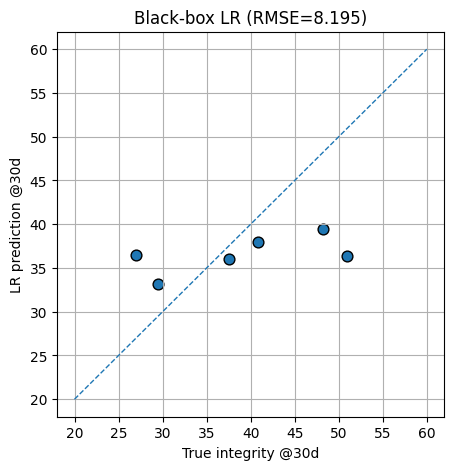

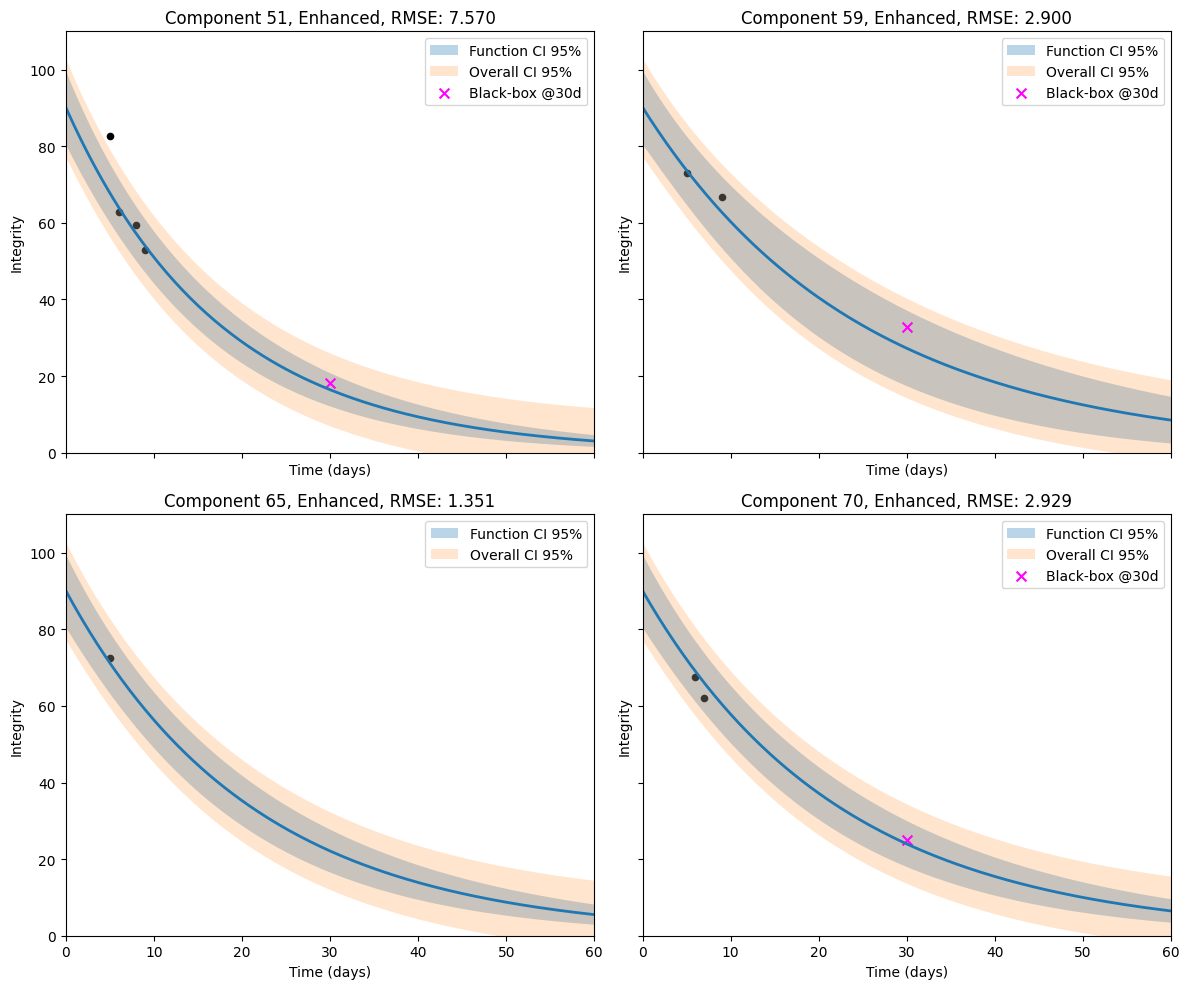

In [16]:
MinObs = 10 
Bayes_Test = [51, 59, 65, 70]
Features = ['mean_int', 'std_int', 'slope', 'intercept', 'last_obs', 
            'log_mean', 'X1','X2','X3','X4','X5']

main_comps, blind_comps = get_main_and_blind_sets(data, MinObs, Bayes_Test)
all_comps = sorted(set(main_comps) | set(blind_comps))

# Build feature summaries
bb_feats = create_features(data, all_comps)

# Fill y30 targets
bb_df = fill_y30_targets(data, bb_feats, enh_samples, X_comp)

# Split into train/test
train_comps, test_comps = split_train_test(main_comps, blind_comps)
train_df = bb_df.loc[train_comps]
test_df  = bb_df.loc[test_comps]

# Prepare matrices
X_train = train_df[Features].values
y_train = train_df['y30'].values
X_test  = test_df[Features].values
y_test  = test_df['y30'].values

# Train and evaluate
lr_model = train_linear_model(X_train, y_train)
rmse = evaluate_model(lr_model, X_test, y_test)

# Overlay on blind set
bb_summaries = bb_feats.reset_index().rename(columns={'index':'comp'})
plot_four_with_blackbox(
    blind_comps[:4],  # first four blind components
    comp_idx, t, y,
    enh_samples, "Enhanced",
    lr_model, bb_summaries, Features
)
